# Driving OpenCDaRR from `mvlse`

Where does P(LoS) cross an acceptable level, as a function of the CNS stack and the airframe?

Five design variables, of three different natures:

| variable | nature | what it is |
|---|---|---|
| `p_reception` | continuous | probability a broadcast reaches a receiver |
| `max_range_m` | continuous | hard surveillance range |
| `kinematics` | **categorical** | multirotor or fixed-wing |
| `pos_ci95_m` | **ordinal** | position uncertainty, 95% CI |
| `vel_ci95_ms` | **ordinal** | velocity uncertainty, 95% CI |

Two continuous, one nominal, two ordinal — 24 categories. This is exactly the mixed-variable
case the hypersphere kernels exist for.

The order below is deliberate. Before handing anything to a Gaussian process, Section 2
measures what the simulator's own estimator noise actually looks like, because that decides
the scale everything after it is modelled on.

## What you need

Both packages importable in the same environment:

```bash
pip install -e /path/to/OpenCDaRR
pip install -e /path/to/MixedVarLSENew
```

In [1]:
import dataclasses
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from opencdarr.cd import StateBased
from opencdarr.cns import Comm, GnssNavigation, LastKnown, SurveillanceRange, lognormal_latency
from opencdarr.config import AircraftUncertaintyConfig, Config, ConflictConfig, SimulationConfig
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.experiment import IPS, MC, Fixed, Models, run_experiment
from opencdarr.fleet import Airframe
from opencdarr.kinematics import FixedWing, Multirotor
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.scenario import PairwiseEncounter

from mvlse import Continuous, DesignSpace, Nominal, Ordinal, run_lse, report, stratified_doe

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

## 1. The simulator: the half that does not vary

### 1.1 The airframes — the categorical variable

`Airframe` bundles a `Performance` envelope with a `Kinematics` integrator, so a mismatched
pair is unrepresentable rather than silently wrong.

**One constraint to respect:** the cruise speed is a property of the *encounter*, not the
airframe, so both airframes fly at the same speed — and it must sit inside both envelopes.
`M600` has `v_max = 18`, `SMALL_FIXEDWING` stalls at `v_min = 12`, so anything in
$[12, 18]$ works. Pick outside that and the scenario builder rejects it.

In [2]:
CRUISE_MS = 15.0    # inside both envelopes: M600 v_max=18, SMALL_FIXEDWING v_min=12
RPZ_M = 50.0

AIRFRAMES = {
    "multirotor": Airframe(M600, Multirotor()),
    "fixedwing":  Airframe(SMALL_FIXEDWING, FixedWing()),
}

### 1.2 Config and Models

`Config` holds the plain numbers; `Models` holds the live CDaRR components. Both are
defaults: the blackbox later overrides only the pieces a design point touches.

In [3]:
BASE_CONFIG = Config(
    seed=0,
    aircraft_uncertainty=AircraftUncertaintyConfig(),
    conflict=ConflictConfig(RPZ_M, 120.0),          # rpz, t_lookahead
    simulation=SimulationConfig(0.5, 250.0, 10.0),  # dt, t_max, done_timeout
)

BASE_MODELS = Models(
    detector=StateBased(),
    resolver=MVP(1.05),
    recovery=PastCPA(True),
    navigation=GnssNavigation(),
    surveillance=LastKnown(),
    airframes=AIRFRAMES["multirotor"],              # overridden per design point
    scenario=PairwiseEncounter(speed=CRUISE_MS, dcpa_max=RPZ_M, tlos=90.0),
)

# the encounter geometry, held fixed for this whole study
GEOMETRY = {"dpsi": Fixed(90.0), "dcpa": Fixed(0.0)}


def build_models(p_reception, max_range_m, kinematics):
    '''BASE_MODELS with the three component-level design variables substituted.'''
    comm = Comm(
        reception_prob=float(p_reception),
        latency=lognormal_latency(median=0.1, sigma=0.25),
        gates=(SurveillanceRange(max_range=float(max_range_m)),),
    )
    return dataclasses.replace(
        BASE_MODELS, airframes=AIRFRAMES[kinematics], communication=comm
    )

---

## 2. Before the Gaussian process: what shape is the estimator's noise?

`mvlse` models the response with a Gaussian process, and when you hand it a standard error
it puts that variance on the covariance diagonal as **Gaussian** observation noise. So it is
worth asking, once, whether that assumption holds for this estimator — and if not, on what
scale it does.

There is a reason to be suspicious. The splitting estimator forms

$$
\hat{P} = \prod_k \text{survival fraction at rung } k
$$

and a **product** of positive random quantities is log-normal in the limit, not normal. If
that is what happens here, the right move is to model $\log_{10} \hat{P}$ rather than
$\hat{P}$ — and it is much better to find that out now than to discover it as a badly
calibrated surrogate later.

The measurement: **fix one design point**, run the estimator **2000 independent times**, and
look at the sampling distribution — raw and on a log scale.

The case is a pairwise crossing tuned to land near **P(LoS) ~ 1e-3**, which is the regime
this estimator exists for, on a well-resolved 8-rung ladder at 400 particles.

In [4]:
STUDY_CASE = {"p_reception": 0.70, "max_range_m": 950.0, "kinematics": "multirotor",
              "pos_ci95_m": 10.0, "vel_ci95_ms": 3.0}

# One well-resolved ladder. A coarser one collapses more often at this particle count
# (7/60 vs 0/60 in a pilot run) — worth knowing, but the shape question is answered on the
# ladder you would actually deploy. Add entries here to compare.
LADDERS = {
    "fine (8 rungs)": (120.0, 105.0, 92.0, 80.0, 70.0, 61.0, 55.0, RPZ_M),
}

N_REPLICATIONS = 2000
N_PARTICLES = 400
N_JOBS = 4              # leave the rest of the machine alone

One `run_experiment` call with `reps=2000` gives 2000 **independent** replications in
`estimate.reps`, each carrying its own `.prob`. That is the efficient way to ask this
question — the replications fan out over `n_jobs` inside the single cell.

The result is cached to disk, because this is a couple of hours of compute on four cores.
Delete the file to recompute.

In [5]:
CACHE = Path("ips_sampling_2000.npz")


def sample_estimator(ladder, reps=N_REPLICATIONS, n_particles=N_PARTICLES, seed=7,
                     n_jobs=N_JOBS):
    '''`reps` independent P-hat values for the fixed study case.'''
    models = build_models(STUDY_CASE["p_reception"], STUDY_CASE["max_range_m"],
                          STUDY_CASE["kinematics"])
    result = run_experiment(
        {**GEOMETRY,
         "pos_ci95": Fixed(float(STUDY_CASE["pos_ci95_m"])),
         "vel_ci95": Fixed(float(STUDY_CASE["vel_ci95_ms"]))},
        models=models,
        backend=IPS(levels=ladder, n_particles=n_particles, reps=reps),
        base_config=BASE_CONFIG, seed=seed, n_jobs=n_jobs, progress=False,
    )
    estimate = result.cell()
    return np.array([r.prob for r in estimate.reps], dtype=float)


if CACHE.exists():
    stored = np.load(CACHE, allow_pickle=False)
    SAMPLES = {name: stored[f"probs__{name}"] for name in LADDERS}
    print(f"loaded {CACHE}: {N_REPLICATIONS} replications x {len(LADDERS)} ladder(s)")
else:
    SAMPLES = {}
    for name, ladder in LADDERS.items():
        t0 = time.perf_counter()
        SAMPLES[name] = sample_estimator(ladder)
        print(f"{name:18s} {N_REPLICATIONS} replications in "
              f"{(time.perf_counter() - t0) / 60:.1f} min", flush=True)
    np.savez(CACHE, **{f"probs__{k}": v for k, v in SAMPLES.items()},
             **{f"ladder__{k}": np.asarray(v) for k, v in LADDERS.items()})
    print(f"saved {CACHE}")

loaded ips_sampling_2000.npz: 2000 replications x 1 ladder(s)


### 2.1 The numbers

A collapsed replication reports exactly `0.0` — the ladder failed to bridge on that draw.
Zeros have no logarithm, so they are counted separately and excluded from the shape
statistics rather than floored into them.

`skew` is 0 for a symmetric distribution. The two normality columns are p-values: **small
means "reject Gaussian"**.

In [6]:
def shape_row(name, probs):
    nonzero = probs[probs > 0]
    log10 = np.log10(nonzero)
    # Shapiro-Wilk is exact only up to n=5000; both scales get the same treatment
    return {
        "ladder": name,
        "rungs": len(LADDERS[name]),
        "P(LoS)": probs.mean(),                 # zeros included, as the estimator reports it
        "collapsed": f"{(probs == 0).sum()}/{len(probs)}",
        "cv": nonzero.std() / nonzero.mean(),
        "skew raw": stats.skew(nonzero),
        "skew log10": stats.skew(log10),
        "kurtosis raw": stats.kurtosis(nonzero),
        "kurtosis log10": stats.kurtosis(log10),
        "normal? raw": stats.shapiro(nonzero).pvalue,
        "normal? log10": stats.shapiro(log10).pvalue,
    }


import pandas as pd

table = pd.DataFrame([shape_row(n, p) for n, p in SAMPLES.items()]).set_index("ladder")
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
table

,rungs,P(LoS),collapsed,cv,skew raw,skew log10,kurtosis raw,kurtosis log10,normal? raw,normal? log10
ladder,,,,,,,,,,
fine (8 rungs),8,0.001432,16/2000,1.048,1.871,-1.063,4.797,1.299,9.637e-43,1.515e-28


### 2.2 The picture

Top row: the raw $\hat{P}$. Bottom row: $\log_{10}\hat{P}$. The dashed curve is the normal
distribution fitted to each sample — the closer the histogram sits to it, the better a
Gaussian noise model describes that scale.

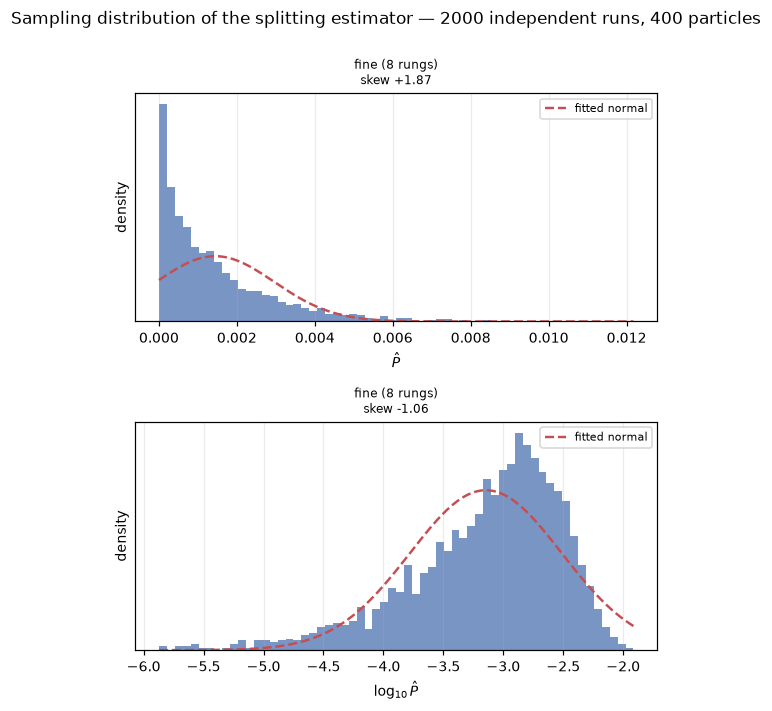

In [7]:
fig, axes = plt.subplots(2, len(SAMPLES), figsize=(5.2 * len(SAMPLES), 6.4), squeeze=False)
for col, (name, probs) in enumerate(SAMPLES.items()):
    nonzero = probs[probs > 0]
    for row, (data, label) in enumerate([(nonzero, r"$\hat{P}$"),
                                         (np.log10(nonzero), r"$\log_{10}\hat{P}$")]):
        ax = axes[row, col]
        ax.hist(data, bins=60, density=True, color="#4c72b0", alpha=0.75, edgecolor="none")
        grid = np.linspace(data.min(), data.max(), 400)
        ax.plot(grid, stats.norm.pdf(grid, data.mean(), data.std()), "--",
                color="#c44e52", lw=1.6, label="fitted normal")
        ax.set_xlabel(label)
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel("density")
        ax.set_title(f"{name}\nskew {stats.skew(data):+.2f}", fontsize=8)
        ax.legend(fontsize=7)
fig.suptitle(f"Sampling distribution of the splitting estimator — "
             f"{N_REPLICATIONS} independent runs, {N_PARTICLES} particles", y=1.00)
fig.tight_layout()
plt.show()

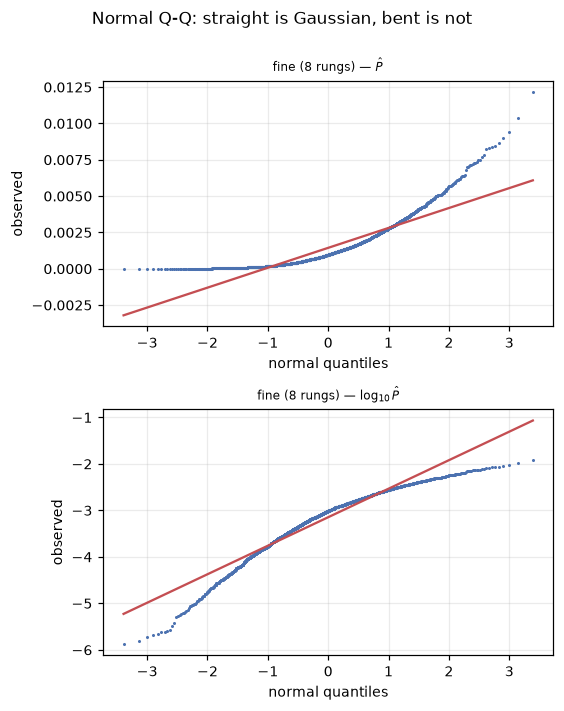

In [8]:
# Q-Q against a normal: a straight line means Gaussian, a bend means it is not
fig, axes = plt.subplots(2, len(SAMPLES), figsize=(5.2 * len(SAMPLES), 6.4), squeeze=False)
for col, (name, probs) in enumerate(SAMPLES.items()):
    nonzero = probs[probs > 0]
    for row, (data, label) in enumerate([(nonzero, r"$\hat{P}$"),
                                         (np.log10(nonzero), r"$\log_{10}\hat{P}$")]):
        ax = axes[row, col]
        stats.probplot(data, dist="norm", plot=ax)
        ax.get_lines()[0].set(marker=".", markersize=2, color="#4c72b0")
        ax.get_lines()[1].set(color="#c44e52", lw=1.5)
        ax.set_title(f"{name} — {label}", fontsize=8)
        ax.set_xlabel("normal quantiles")
        ax.set_ylabel("observed")
fig.suptitle("Normal Q-Q: straight is Gaussian, bent is not", y=1.00)
fig.tight_layout()
plt.show()

### 2.3 What the blackbox actually hands over

One more step before concluding. The number a `reps=R` blackbox returns is not a single
draw — it is the **mean of `R` replications**, and averaging pulls a skewed distribution
back towards Gaussian by the central limit theorem. So the question is not "is one
replication Gaussian" but "is the mean of `R` Gaussian enough".

Resample from the 2000 draws to see how fast that happens.

In [9]:
rng = np.random.default_rng(0)
REPS_TO_TRY = (1, 2, 4, 8, 16)

rows = []
for name, probs in SAMPLES.items():
    for r in REPS_TO_TRY:
        means = rng.choice(probs, size=(4000, r)).mean(axis=1)   # includes the zeros
        positive = means[means > 0]
        rows.append({
            "ladder": name, "reps": r,
            "skew raw": stats.skew(positive),
            "skew log10": stats.skew(np.log10(positive)),
            "P(mean == 0)": f"{(means == 0).mean():.3%}",
        })
pd.DataFrame(rows).set_index(["ladder", "reps"])

skew raw  skew log10 P(mean == 0)
ladder         reps                                   
fine (8 rungs) 1        1.844      -1.031       0.650%
               2        1.285      -1.025       0.000%
               4       0.9948      -0.641       0.000%
               8       0.6676     -0.4463       0.000%
               16       0.448       -0.36       0.000%

The `P(mean == 0)` column is the practical one: it is how often a blackbox at that `reps`
returns a value with no logarithm at all, which you then have to floor.

### 2.4 Reading it, and what it decides

Two questions, answered by the tables and plots above rather than asserted here:

1. **Which scale is closer to Gaussian?** Compare `skew raw` with `skew log10`, and the two
   Q-Q rows. Whichever is straighter is the scale to model on.
2. **How many replications do you need?** From Section 2.3, the smallest `reps` whose skew
   is acceptable and whose `P(mean == 0)` is small enough to ignore.

Whatever the answer, it feeds straight into the blackbox below: the scale you return, the
standard error you attach to it, and the `reps` you buy.

> A note on what is *not* being claimed. This checks the noise at **one** design point. The
> noise scale varies across the space — that is exactly why `mvlse` takes a per-point
> standard error instead of one global value — but the *shape* is a property of the
> estimator, and one well-sampled point is enough to establish it.

---

## 3. Where each variable lands in OpenCDaRR

This is the whole integration. The five variables reach the simulator by three different
routes, and knowing which is which is most of the work:

| `mvlse` variable | route into OpenCDaRR |
|---|---|
| `pos_ci95_m` | a **declared axis** — `pos_ci95` is a wired parameter, so `Fixed(value)` |
| `vel_ci95_ms` | a **declared axis** — `vel_ci95`, likewise |
| `p_reception` | a **component field** — rebuild `Comm(reception_prob=...)` per point |
| `max_range_m` | a **component field** — the `SurveillanceRange` gate on that `Comm` |
| `kinematics` | a **component** — `Models.airframes`, an `Airframe(perf, kinematics)` |

`run_experiment` accepts as axes only the parameters it threads end to end (`pos_ci95`,
`vel_ci95`, `dpsi`, `dcpa`, `rpz`, …). Anything living *inside* a component is varied by
constructing that component and passing it through `Models` — which is what `build_models`
above already does.

## 4. The design space

Declare it in physical units, with the nature of each variable stated. `Ordinal` says the
levels have a real order; `Nominal` says they do not. That distinction is what the
correlation function is allowed to use.

In [10]:
space = DesignSpace({
    "p_reception": Continuous(0.20, 1.00),
    "max_range_m": Continuous(200.0, 3000.0),
    "kinematics":  Nominal(["multirotor", "fixedwing"]),
    "pos_ci95_m":  Ordinal([3.0, 10.0, 30.0, 92.6]),     # ADS-L accuracy classes [m]
    "vel_ci95_ms": Ordinal([1.0, 3.0, 10.0]),            # [m/s]
})

print(space.describe())
print(f"\n{space.m} categories x 2 continuous dimensions")

DesignSpace: q=2 continuous, r=3 discrete, m=24 categories
  normalize = True  (continuous columns mapped to [0, 1])

  column name             nature     physical                     what the model sees
  ------ ---------------- ---------- ---------------------------- ----------------------------
  0      p_reception      continuous [0.2, 1]                     [0, 1]
  1      max_range_m      continuous [200, 3000]                  [0, 1]
  2      kinematics       nominal    multirotor, fixedwing        level index 0..1
  3      pos_ci95_m       ordinal    3.0, 10.0, 30.0, 92.6        level index 0..3
  4      vel_ci95_ms      ordinal    1.0, 3.0, 10.0               level index 0..2

24 categories x 2 continuous dimensions


## 5. The blackbox

One `run_experiment` call per design point, with **every axis `Fixed`** — that is the
single-condition case.

Why one call per point rather than one sweep: `Sweep` builds a *cross-product*, and the
level-set loop asks for arbitrary combinations, not a grid. An all-`Fixed` declaration is
exactly one condition, which is what a design point is.

`n_jobs=-1` then spends the whole worker budget **inside** that one cell, which is what you
want. Do not also wrap this in a joblib pool — nesting two pools does not end well.

**Returning `(value, standard_error)` turns on the heteroscedastic path**, which is the
whole reason Section 2 mattered: you are asserting that the observation noise is Gaussian
with that scale, so return the value on whichever scale made that true.

Section 2 said that scale is $\log_{10}$, and that applies to plain Monte Carlo too — for a
second reason that has nothing to do with skew. A Gaussian process with a constant trend is
**unbounded**, so fitted on a raw probability it will happily predict $P < 0$ in the safe
corners of the design space. Modelling $\log_{10} P$ makes that unrepresentable: every
prediction exponentiates back to a positive probability.

The one wrinkle is that Monte Carlo returns exact zeros, which have no logarithm. Rather
than floor them, use the **Jeffreys-corrected** proportion $(k + \tfrac12)/(n+1)$: never
exactly zero, so no special case, and $0/300$ honestly becomes "small, known to about a
decade" instead of "exactly zero, known perfectly".

This first blackbox uses plain Monte Carlo, cheap enough to run here. Section 9 swaps in
the splitting estimator for a genuinely rare target.

In [11]:
N_ENCOUNTERS = 300     # per design point; raise for a real study


def p_los_blackbox(points):
    '''log10 P(LoS) per run, with its standard error, one per design point.'''
    out = []
    for p in points:
        models = build_models(p["p_reception"], p["max_range_m"], p["kinematics"])
        result = run_experiment(
            {**GEOMETRY,
             "pos_ci95": Fixed(float(p["pos_ci95_m"])),
             "vel_ci95": Fixed(float(p["vel_ci95_ms"]))},
            models=models,
            backend=MC(n_encounters=N_ENCOUNTERS),
            base_config=BASE_CONFIG,
            seed=7,
            n_jobs=-1,          # spend the budget inside this one cell
            progress=False,
        )
        estimate = result.cell()          # the raw MonteCarloEstimate; one condition, no args

        n, k = estimate.n_encounters, estimate.n_los
        # Jeffreys-corrected proportion: (k + 1/2) / (n + 1) is never exactly 0, so every
        # point has a logarithm -- no flooring branch, and 0/300 still says "small, but I
        # only know it to within a decade or so" rather than "exactly zero".
        p_hat = (k + 0.5) / (n + 1.0)
        se_p = np.sqrt(p_hat * (1.0 - p_hat) / n)
        # delta method onto log10: se_log = se_p / (p ln 10)
        se_log = float(se_p / (p_hat * np.log(10.0)))
        out.append((float(np.log10(p_hat)), se_log))
    return out

Sanity-check it on a handful of points before spending a budget on it.

In [12]:
probe_points = space.decode(stratified_doe(space, n_per_category=1, seed=0))[:6]
t0 = time.perf_counter()
probe = p_los_blackbox(probe_points)
print(f"{len(probe)} points in {time.perf_counter() - t0:.1f}s "
      f"({(time.perf_counter() - t0) / len(probe):.2f}s each)\n")
for pt, (y, se) in zip(probe_points, probe):
    print(f"p_rx={pt['p_reception']:.2f}  range={pt['max_range_m']:6.0f}m  "
          f"{pt['kinematics']:11s} pos={pt['pos_ci95_m']:5.1f}  vel={pt['vel_ci95_ms']:4.1f}"
          f"   ->  log10 P = {y:+.3f} +- {se:.3f}   (P = {10 ** y:.2e})")

6 points in 22.6s (3.77s each)

p_rx=0.71  range=   955m  multirotor  pos=  3.0  vel= 1.0   ->  log10 P = -2.780 +- 0.615   (P = 1.66e-03)
p_rx=0.23  range=   246m  multirotor  pos=  3.0  vel= 3.0   ->  log10 P = -0.537 +- 0.039   (P = 2.91e-01)
p_rx=0.85  range=  2756m  multirotor  pos=  3.0  vel=10.0   ->  log10 P = -1.934 +- 0.231   (P = 1.16e-02)
p_rx=0.69  range=  2243m  multirotor  pos= 10.0  vel= 1.0   ->  log10 P = -2.780 +- 0.615   (P = 1.66e-03)
p_rx=0.63  range=  2818m  multirotor  pos= 10.0  vel= 3.0   ->  log10 P = -2.780 +- 0.615   (P = 1.66e-03)
p_rx=0.85  range=   208m  multirotor  pos= 10.0  vel=10.0   ->  log10 P = -0.727 +- 0.052   (P = 1.88e-01)


## 6. Run the level-set estimation

`threshold` is the P(LoS) you care about, **in the units the blackbox returns** — so
`np.log10(0.02)` for a 2% target. Everything at or below it is the acceptable set.

Budget the initial design first: `n_init_per_category * 24` points are spent before the loop
acquires anything. With 24 categories, keep `n_init_per_category` at 1 or 2 and let the
straddle place the rest — it allocates far better than a uniform design, because it can see
where the boundary is.

`store=` writes every evaluation to disk, so re-running with a larger budget pays only for
the new points. With a simulator this slow, always pass it.

In [13]:
result = run_lse(
    space,
    p_los_blackbox,
    threshold=np.log10(0.02),   # P(LoS) <= 2%, in log10 units
    method="hs_dim",
    n_init_per_category=1,      # 24 initial points
    max_evaluations=180,
    batch_size=1,
    store="cdarr_p_los.jsonl",
    keep_snapshots=True,
    seed=7,
    verbose=False,
)

print(result.summary())

level set: <= -1.69897   method: hs_dim (squar_exp)
evaluations: 101 (24 initial + 77 acquired) in 78 rounds, 680.7s
stopped by: plateau (classification moved <= 0.5% for 10 rounds)
final: max straddle=+0.2157  ambiguous=23.1%


Read `stop_reason` every time. `budget` next to a still-positive `max_straddle` means the run
was cut short, not that it converged — raise `max_evaluations` and re-run, and the store
makes the repeat cheap.

**A noisy blackbox changes which stopping rule can fire.** The posterior standard deviation
cannot fall below the observation noise. At 300 encounters the standard error near the
threshold is roughly `0.18` decades, and a point exactly on the boundary needs the interval
to exclude it — so the straddle can stay positive no matter how many points you add, and the
`confident` rule may never fire. That is not a failure; it is the model correctly reporting
that 300 encounters per point cannot resolve a 2% probability to that precision.

Your levers, in order: raise `N_ENCOUNTERS` to lower the noise floor (the error falls as
$1/\sqrt{n}$), move to `IPS` if the threshold is genuinely rare, or accept the `plateau`
rule and read `ambiguous_fraction` as the honest measure of what is left unresolved.

In [14]:
result.to_dataframe().head(10)

,p_reception,max_range_m,kinematics,pos_ci95_m,vel_ci95_ms,y,se,initial
0,0.3029,1598,multirotor,3,1,-2.78,0.6147,True
1,0.6812,280.3,multirotor,3,3,-1.604,0.1569,True
2,0.3183,2799,multirotor,3,10,-1.382,0.1205,True
3,0.2563,563.4,multirotor,10,1,-1.934,0.2312,True
4,0.9587,1941,multirotor,10,3,-2.302,0.3543,True
5,0.4952,1632,multirotor,10,10,-2.081,0.274,True
6,0.7303,970.9,multirotor,30,1,-2.78,0.6147,True
7,0.3104,2407,multirotor,30,3,-2.302,0.3543,True
8,0.7363,1635,multirotor,30,10,-1.666,0.1688,True
9,0.8534,1737,multirotor,92.6,1,-2.78,0.6147,True


In [15]:
result.history().tail(8)

,round,n_evaluations,max_straddle,ambiguous_fraction,flip_fraction,seconds
70,70,94,0.253,0.2354,0.004346,8.728
71,71,95,0.2384,0.2319,0.002834,8.607
72,72,96,0.2359,0.2317,0.003685,20
73,73,97,0.2246,0.2278,0.003496,14.05
74,74,98,0.2237,0.227,0.0005669,12.35
75,75,99,0.2303,0.2303,0.004252,16.06
76,76,100,0.2164,0.2304,0.002834,21.81
77,77,101,0.2157,0.2314,0.002079,6.845


## 7. What did it learn about the discrete variables?

The learned matrices *are* the level-to-level correlations. Check them before trusting
anything else.

For the two **ordinal** variables a sound fit tends to come out monotone — neighbouring
accuracy classes more alike than distant ones — without having been told there is an order.
For the **nominal** one, any pattern is admissible; a low value means the two airframes
behave like genuinely different problems.

In [16]:
for name, matrix in result.level_correlations().items():
    levels = space.variable(name).levels
    print(f"\n{name}  ({', '.join(str(x) for x in levels)})")
    print(np.round(matrix, 3))


kinematics  (multirotor, fixedwing)
[[1.    0.964]
 [0.964 1.   ]]

pos_ci95_m  (3.0, 10.0, 30.0, 92.6)
[[1.    0.975 0.914 0.818]
 [0.975 1.    0.919 0.751]
 [0.914 0.919 1.    0.928]
 [0.818 0.751 0.928 1.   ]]

vel_ci95_ms  (1.0, 3.0, 10.0)
[[1.    0.625 0.465]
 [0.625 1.    0.981]
 [0.465 0.981 1.   ]]


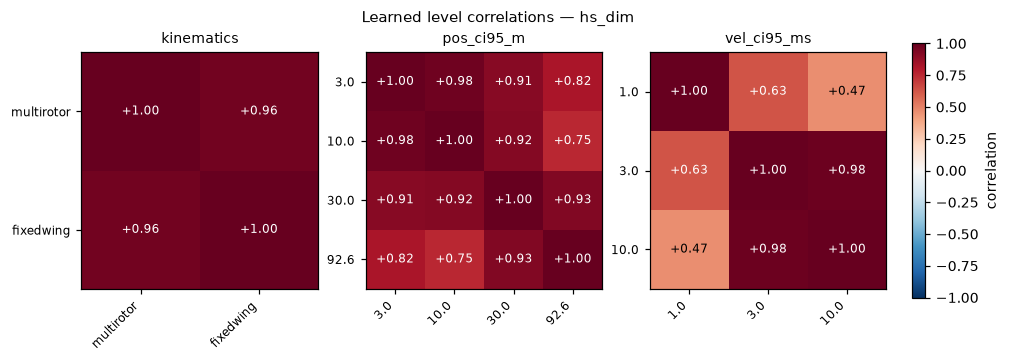

In [17]:
report.level_correlation_heatmap(result);

## 8. The boundary

`boundary_panels` needs exactly two continuous variables, which is what this space has — one
panel per category, `p_reception` against `max_range_m`.

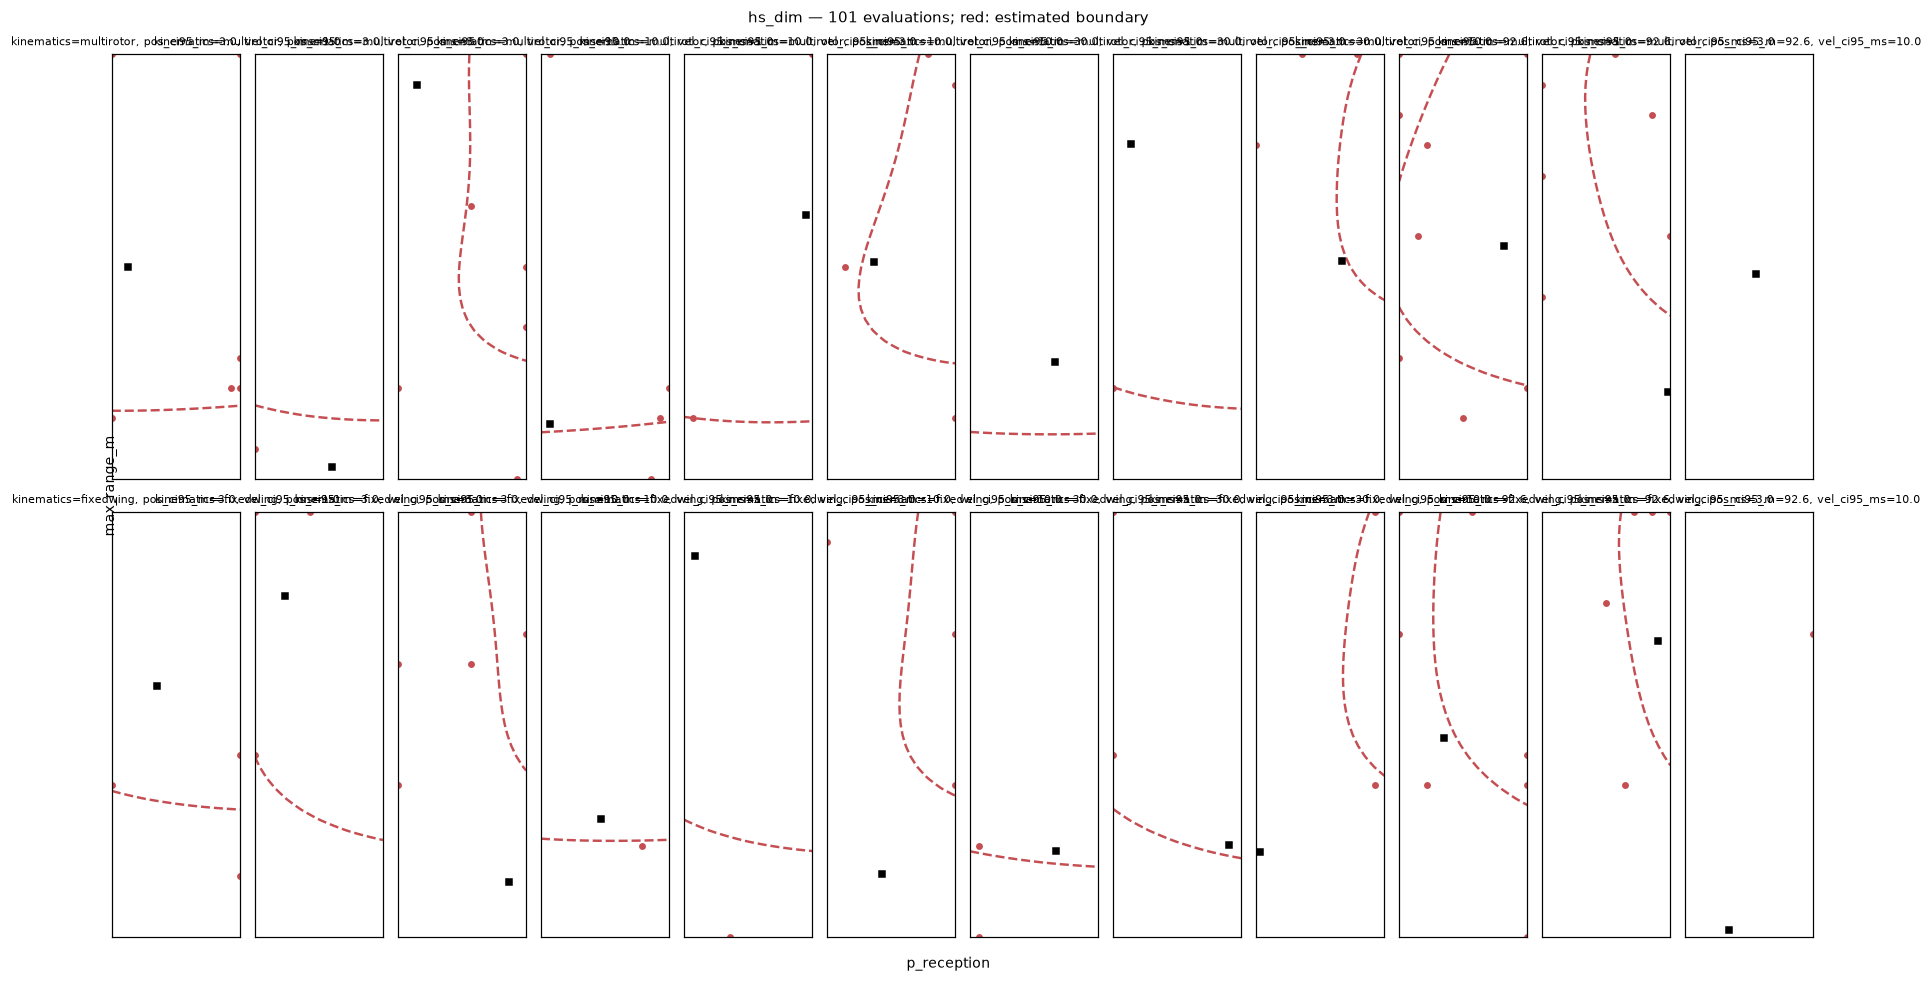

In [18]:
report.boundary_panels(result, figsize=(16, 9));

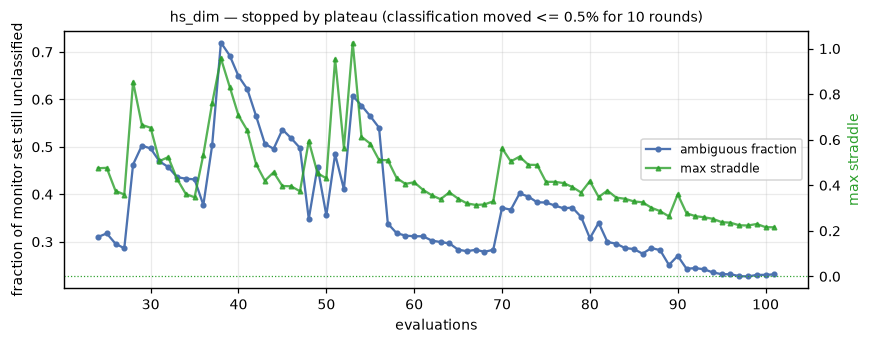

In [19]:
report.convergence(result);

### Query the surrogate

The point of the fit: ask about configurations you never simulated.

In [20]:
queries = [
    {"p_reception": 0.95, "max_range_m": 2500.0, "kinematics": "multirotor",
     "pos_ci95_m": 3.0,  "vel_ci95_ms": 1.0},
    {"p_reception": 0.40, "max_range_m":  400.0, "kinematics": "multirotor",
     "pos_ci95_m": 92.6, "vel_ci95_ms": 10.0},
    {"p_reception": 0.95, "max_range_m": 2500.0, "kinematics": "fixedwing",
     "pos_ci95_m": 3.0,  "vel_ci95_ms": 1.0},
]

mu, sd = result.predict(queries)
inside, unsure = result.inside(queries), result.uncertain(queries)
for q, m, sdev, ok, u in zip(queries, mu, sd, inside, unsure):
    lo, hi = 10 ** (m - 1.96 * sdev), 10 ** (m + 1.96 * sdev)
    print(f"{q['kinematics']:11s} p_rx={q['p_reception']:.2f} range={q['max_range_m']:6.0f}m "
          f"pos={q['pos_ci95_m']:5.1f} vel={q['vel_ci95_ms']:4.1f}"
          f"  ->  P(LoS) = {10 ** m:.2e}  95% CI [{lo:.1e}, {hi:.1e}]"
          f"   acceptable={str(ok):5s}  unresolved={u}")

print("\nEvery prediction is a positive probability by construction — a consequence of "
      "modelling log10 P rather than P.")

multirotor  p_rx=0.95 range=  2500m pos=  3.0 vel= 1.0  ->  P(LoS) = 3.52e-04  95% CI [7.7e-05, 1.6e-03]   acceptable=True   unresolved=False
multirotor  p_rx=0.40 range=   400m pos= 92.6 vel=10.0  ->  P(LoS) = 4.37e-01  95% CI [2.0e-01, 9.3e-01]   acceptable=False  unresolved=False
fixedwing   p_rx=0.95 range=  2500m pos=  3.0 vel= 1.0  ->  P(LoS) = 8.20e-04  95% CI [1.6e-04, 4.2e-03]   acceptable=True   unresolved=False

Every prediction is a positive probability by construction — a consequence of modelling log10 P rather than P.


---

## 9. Rare thresholds — swap `MC` for `IPS`

Plain Monte Carlo cannot resolve a target like $10^{-5}$: at 300 encounters the standard
error swamps it and most points return exactly zero. That is what the splitting estimator is
for, and Section 2 already told you which scale to model it on and how many replications to
buy.

The transformation of the standard error follows the scale. On $\log_{10}$,

$$
se_{\log_{10}} = \frac{se_{\hat{P}}}{\hat{P} \ln 10}
$$

with $se_{\hat{P}}$ taken from the spread across replications. A collapsed estimate is
exactly zero and has no logarithm — floor it, well below any threshold you care about.

In [21]:
LADDER = LADDERS["fine (8 rungs)"]     # the ladder characterised in Section 2
Y_FLOOR = -9.0                         # log10 P(LoS) floor for a fully collapsed estimate
SE_CAP = 2.0                           # decades
N_REPS_BLACKBOX = 8                    # from Section 2.3


def log_p_los_blackbox(points):
    '''log10 P(LoS) with its standard error, via the rare-event splitting estimator.'''
    out = []
    for p in points:
        models = build_models(p["p_reception"], p["max_range_m"], p["kinematics"])
        result = run_experiment(
            {**GEOMETRY,
             "pos_ci95": Fixed(float(p["pos_ci95_m"])),
             "vel_ci95": Fixed(float(p["vel_ci95_ms"]))},
            models=models,
            backend=IPS(levels=LADDER, n_particles=N_PARTICLES, reps=N_REPS_BLACKBOX),
            base_config=BASE_CONFIG, seed=7, n_jobs=-1, progress=False,
        )
        estimate = result.cell()

        probs = np.array([r.prob for r in estimate.reps], dtype=float)
        p_hat = float(estimate.p_los_run)
        if p_hat <= 0.0:                       # every replication collapsed
            out.append((Y_FLOOR, SE_CAP))
            continue
        se_p = float(probs.std(ddof=1) / np.sqrt(len(probs))) if len(probs) > 1 else p_hat
        se_log = float(np.clip(se_p / (p_hat * np.log(10.0)), 0.02, SE_CAP))
        out.append((float(np.log10(p_hat)), se_log))
    return out

In [22]:
t0 = time.perf_counter()
(y, se), = log_p_los_blackbox([STUDY_CASE])
elapsed = time.perf_counter() - t0
print(f"one IPS point: log10 P(LoS) = {y:.3f} +- {se:.3f}   ->  P(LoS) = {10 ** y:.3e}")
print(f"[{elapsed:.1f}s per point; a 400-point study is about "
      f"{400 * elapsed / 3600:.1f} core-hours]")

one IPS point: log10 P(LoS) = -3.067 +- 0.103   ->  P(LoS) = 8.564e-04
[73.8s per point; a 400-point study is about 8.2 core-hours]


The loop is then identical, on the log scale:

```python
rare = run_lse(
    space, log_p_los_blackbox,
    threshold=np.log10(1e-5),        # the level set, in log10 units
    method="hs_dim",
    n_init_per_category=1,
    max_evaluations=400,
    store="cdarr_log_p_los.jsonl",
    seed=7,
)
```

### Diagnosing a collapsed ladder

`n_collapsed` counts replications that reached an empty level. Inspect it directly when a
point comes back on the floor:

In [23]:
def ips_diagnostics(point, ladder=LADDER):
    models = build_models(point["p_reception"], point["max_range_m"], point["kinematics"])
    res = run_experiment(
        {**GEOMETRY, "pos_ci95": Fixed(float(point["pos_ci95_m"])),
         "vel_ci95": Fixed(float(point["vel_ci95_ms"]))},
        models=models, backend=IPS(levels=ladder, n_particles=N_PARTICLES, reps=8),
        base_config=BASE_CONFIG, seed=7, n_jobs=-1, progress=False)
    est = res.cell()
    # A collapsed replication stops at the rung it died on, so the survival tuples are
    # RAGGED — averaging them with a plain np.mean raises. Average each rung over the
    # replications that actually reached it, which is what OpenCDaRR's own repr does.
    depth = max(len(r.survival) for r in est.reps)
    survival = [float(np.mean([r.survival[k] for r in est.reps if len(r.survival) > k]))
                for k in range(depth)]
    print(f"  p_los_run = {est.p_los_run:.3e}   collapsed {est.n_collapsed}/{len(est.reps)}")
    print(f"  rungs reached: {depth}/{len(ladder)}")
    print(f"  mean survival per rung: {[round(v, 3) for v in survival]}")


print("the study case (~1e-3):")
ips_diagnostics(STUDY_CASE)

print("\na far safer configuration:")
ips_diagnostics({"p_reception": 0.90, "max_range_m": 2500.0, "kinematics": "multirotor",
                 "pos_ci95_m": 3.0, "vel_ci95_ms": 1.0})

the study case (~1e-3):


  p_los_run = 8.564e-04   collapsed 0/8
  rungs reached: 8/8
  mean survival per rung: [0.302, 0.762, 0.736, 0.594, 0.455, 0.243, 0.3, 0.244]

a far safer configuration:


  p_los_run = 0.000e+00   collapsed 8/8
  rungs reached: 8/8
  mean survival per rung: [0.194, 0.76, 0.707, 0.538, 0.434, 0.147, 0.002, 0.0]


Note the raggedness handled in that helper: a replication that collapses stops at the rung
it died on, so `r.survival` is *shorter* for those — averaging the tuples directly raises
`ValueError: inhomogeneous shape`. `rungs reached` below `len(ladder)` is itself the
collapse signature.

A survival fraction that falls off a cliff between two rungs is the ladder asking for an
intermediate one; one that collapses at every rung is asking for more particles. A
configuration far safer than your threshold will collapse whatever you do, and flooring it is
the right answer — it is unambiguously inside the acceptable set, which is all the level set
needs to know.

---

# Practicalities

## A. Caching, at two levels

Both packages can cache, and they cache different things.

**`mvlse`'s `store=`** keys on the *design point*. A re-run of the same study skips every
point it has already evaluated. This is the one you want by default.

**OpenCDaRR's `cache=True`** keys on the *condition* — the resolved config, the component
identities, the backend, the seed, and the library's code fingerprint. It survives across
different `mvlse` studies, and across changes to the design space that leave the underlying
condition unchanged.

Use both when a study is expensive:

```python
result = run_experiment(..., cache=True)      # inside the blackbox
run_lse(..., store="cdarr_p_los.jsonl")       # around it
```

OpenCDaRR refuses to cache a component it cannot identify, raising `CacheIdentityError`
rather than keying on something ambiguous.

## B. Parallelism — pick one level, not two

`run_experiment(n_jobs=-1)` on a single condition spends the whole budget **inside** the
cell: Monte Carlo slices its encounter fan-out, and the splitting estimator shards each
level. That is the right level here, because the level-set loop hands over one point at a
time.

So do **not** wrap the blackbox in `mvlse.parallel`. Two nested pools will fight, and loky
does not survive it.

If you want several design points in flight at once, raise `batch_size` and keep the fan-out
inside OpenCDaRR:

```python
run_lse(space, p_los_blackbox, threshold=0.02,
        batch_size=4, min_batch_distance=0.15, ...)
```

`min_batch_distance` stops a batch piling onto one patch of boundary.

## C. Comparing correlation functions

The methods are interchangeable, so you can ask which discrete-correlation assumption your
problem actually needs:

```python
for method in ["dc", "gower", "hs_dim"]:
    r = run_lse(space, p_los_blackbox, threshold=0.02, method=method,
                store="cdarr_p_los.jsonl",   # the SAME store: no simulation is repeated
                max_evaluations=180, seed=7, verbose=False)
    print(method, r.n_evaluations, r.stop_reason)
```

Sharing one store makes this nearly free where the runs overlap.

---

## Where to go next

- [`custom_blackbox.ipynb`](custom_blackbox.ipynb) — the full `mvlse` API on a cheap
  function, including every accepted blackbox return shape
- [`../docs/CHOOSING.md`](../docs/CHOOSING.md) — which `method` to use, and the checks worth
  running after any fit
- [`../docs/FORMULA_SHEET.md`](../docs/FORMULA_SHEET.md) — the Gaussian-process machinery
  beside the paper it comes from